In [9]:
import pandas as pd

# Load cleaned CSV files
cbe_df = pd.read_csv("../notebooks/processed_cbe_data_with_sentiment_reviews.csv",)
boa_df = pd.read_csv("../notebooks/processed_boa_data_with_sentiment_reviews.csv",)
dashen_df = pd.read_csv("../notebooks/processed_dashen_data_with_sentiment_reviews.csv",)


Combine and Preprocess Data

In [10]:
# Combine all data
combined_df = pd.concat([cbe_df, boa_df, dashen_df], ignore_index=True)

# Ensure correct types
combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df['sentiment_score'] = pd.to_numeric(combined_df['sentiment_score'], errors='coerce')
combined_df['rating'] = pd.to_numeric(combined_df['rating'], errors='coerce')

# Drop rows with missing sentiment_score or rating
combined_df.dropna(subset=['sentiment_score', 'rating'], inplace=True)


In [11]:
from collections import Counter

def find_top_themes(df, sentiment_label, top_n=5):
    filtered = df[df['sentiment'] == sentiment_label]
    all_themes = [theme for sublist in filtered['themes'].dropna() for theme in eval(sublist)]
    return Counter(all_themes).most_common(top_n)

# Example: Pain points (negative), Drivers (positive)
pain_points = {}
drivers = {}
for bank, df in [("CBE", cbe_df), ("BOA", boa_df), ("Dashen", dashen_df)]:
    pain_points[bank] = find_top_themes(df, "Negative")
    drivers[bank] = find_top_themes(df, "Positive")


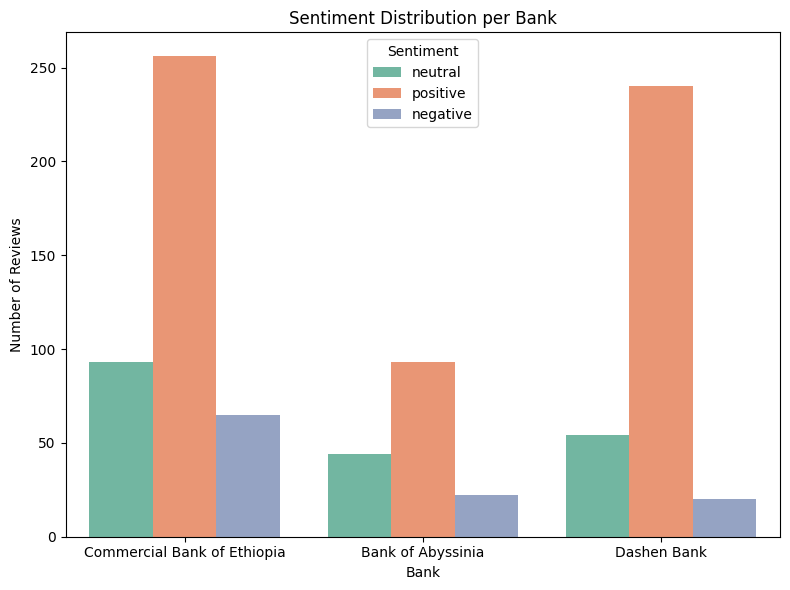

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(data=combined_df, x='bank', hue='sentiment', palette='Set2')
plt.title("Sentiment Distribution per Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.savefig("plots/sentiment_distribution.png")
plt.show()


C:\Users\PC\AppData\Local\Temp\ipykernel_13880\3296934857.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='bank', y='sentiment_score', palette='Set3')


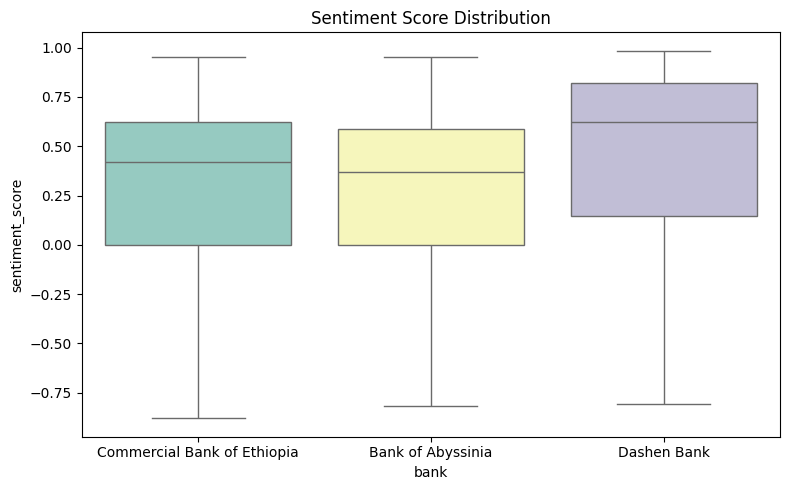

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=combined_df, x='bank', y='sentiment_score', palette='Set3')
plt.title("Sentiment Score Distribution")
plt.tight_layout()
plt.savefig("plots/sentiment_score_boxplot.png")
plt.show()



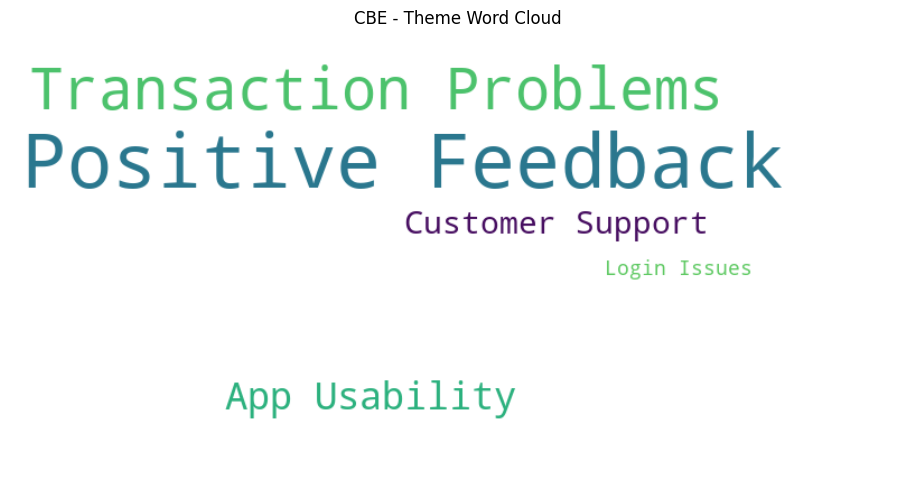

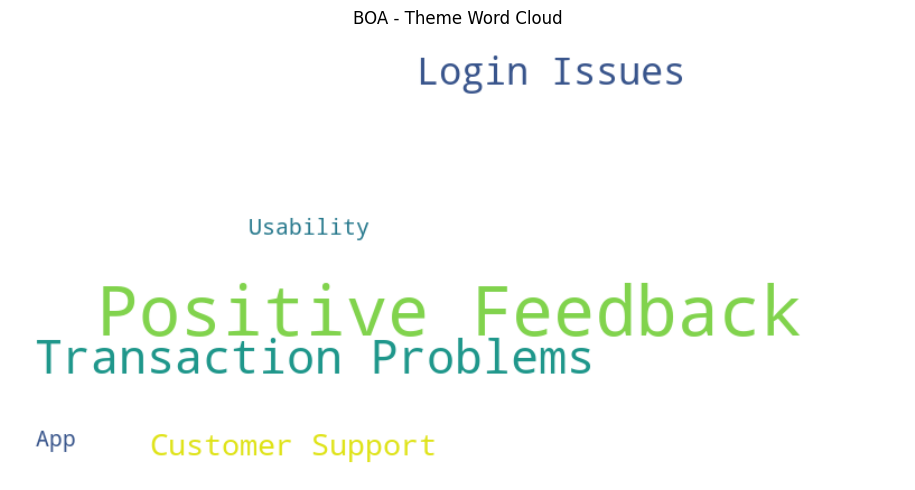

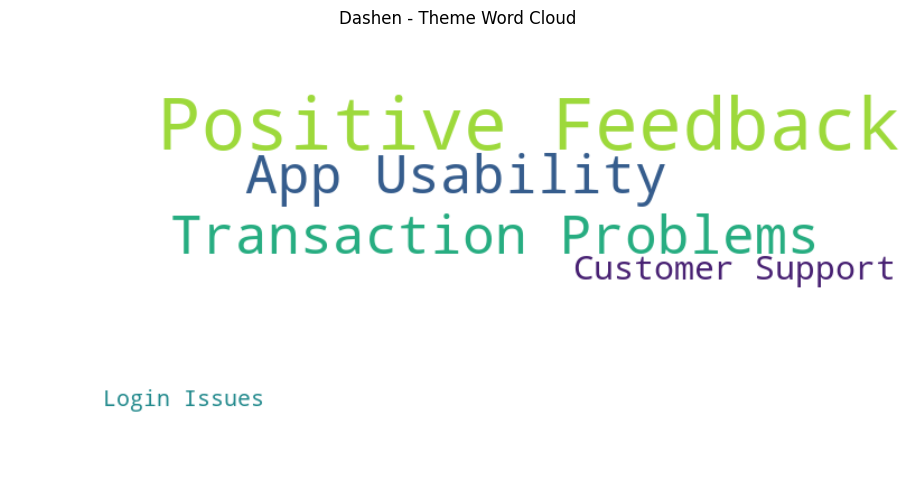

In [17]:
from wordcloud import WordCloud

def plot_theme_cloud(df, bank_name):
    all_themes = [theme for sublist in df['themes'].dropna() for theme in eval(sublist)]
    text = " ".join(all_themes)
    wordcloud = WordCloud(background_color='white', width=800, height=400).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"{bank_name} - Theme Word Cloud")
    plt.tight_layout()
    plt.savefig(f"plots/{bank_name.lower()}_theme_cloud.png")
    plt.show()

plot_theme_cloud(cbe_df, "CBE")
plot_theme_cloud(boa_df, "BOA")
plot_theme_cloud(dashen_df, "Dashen")
